# Вариант 10. Комплексный EDA с мини-дашбордом

## Финальный проект: комплексный анализ датасета `tips`

### Цель проекта

Провести полный исследовательский анализ данных, создать дополнительные метрики, изучить категории, зависимости и подготовить интерактивные графики для презентации результатов.

---

## Задание 1. Загрузка и описание данных

Необходимо:

1. Импортировать:
   - `pandas`;
   - `seaborn`;
   - `matplotlib.pyplot`.
2. Загрузить датасет `tips`.
3. Вывести первые строки.
4. Вывести `info()`.
5. Вывести размер таблицы и список столбцов.
6. Описать каждую переменную.

In [1]:
# Импортируем библиотеки

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Загружаем датасет

df = sns.load_dataset('tips')

In [3]:
# Выведем первые строки

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
# Выведем информацию о датасете

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [5]:
# Выведем размер таблицы и список столбцов

print('Количество строк в таблице:', df.shape[0])
print('Количество столбцов в таблице:', df.shape[1])
print('Список столбцов:', df.columns.tolist())

Количество строк в таблице: 244
Количество столбцов в таблице: 7
Список столбцов: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


### Переменные датасета

| Переменная | Описание |
|---|---|
| `total_bill` | Общая сумма счета |
| `tip` | Размер чаевых |
| `sex` | Пол клиента |
| `smoker` | Курящий клиент или нет |
| `day` | День недели |
| `time` | Время посещения: обед или ужин |
| `size` | Размер компании |

---

## Задание 2. Проверка качества данных

Необходимо:

1. Проверить пропуски.
2. Проверить дубликаты.
3. Проверить уникальные значения категориальных признаков.
4. Посчитать количество наблюдений по `day`, `time`, `size`.
5. Сделать вывод, требуется ли очистка.

In [6]:
# Проверим наличие пропусков

df.isna().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


Вывод: пропуски в датасете отсутствуют

In [7]:
# Проверим наличие дубликатов

df.duplicated().sum()

np.int64(1)

In [8]:
# Посмотрим на уникальную строку и ее дубликат

df[df.duplicated(keep=False)]

,total_bill,tip,sex,smoker,day,time,size
198,13.0,2.0,Female,Yes,Thur,Lunch,2
202,13.0,2.0,Female,Yes,Thur,Lunch,2


Вывод: в датасете одна строка является дубликатом. Это вполне могла быть компания людей, которая заказала на такую же сумму, что и другая компания людей, и оставила такие же чаевые. Поэтому не будем удалять эту строку

In [9]:
# Проверим уникальные значения категориальных признаков

for col in df.select_dtypes(include=['category']).columns:
  print(col, df[col].unique())

sex ['Female', 'Male']
Categories (2, object): ['Male', 'Female']
smoker ['No', 'Yes']
Categories (2, object): ['Yes', 'No']
day ['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']
time ['Dinner', 'Lunch']
Categories (2, object): ['Lunch', 'Dinner']


Посчитаем количество наблюдений по day, time, size

In [10]:
# Посчитаем количество наблюдений по day

df['day'].value_counts().reset_index()

,day,count
0,Sat,87
1,Sun,76
2,Thur,62
3,Fri,19


In [11]:
# Посчитаем количество наблюдений по time

df['time'].value_counts().reset_index()

,time,count
0,Dinner,176
1,Lunch,68


In [12]:
# Посчитаем количество наблюдений по size

df['size'].value_counts().reset_index()

,size,count
0,2,156
1,3,38
2,4,37
3,5,5
4,1,4
5,6,4


Вывод: пропуски в датасете отсутствуют. Одна строка является дубликатом. Уникальные значения категориальных признаков вполне соответствуют этим признакам. По количеству наблюдений наибольшее число заказов происходит в субботу вечером на двух человек, что тоже является нормой. Очистка данных не требуется

---

## Задание 3. Feature engineering

Создайте дополнительные признаки:

```python
tips['tip_percent'] = tips['tip'] / tips['total_bill'] * 100
tips['bill_per_person'] = tips['total_bill'] / tips['size']
tips['tip_per_person'] = tips['tip'] / tips['size']
```

Необходимо:

1. Создать новые признаки.
2. Вывести первые строки.
3. Получить статистику по новым признакам.
4. Объяснить смысл каждой метрики.

In [13]:
# Создадим дополнительные признаки

df['tip_percent'] = df['tip'] / df['total_bill'] * 100
df['bill_per_person'] = df['total_bill'] / df['size']
df['tip_per_person'] = df['tip'] / df['size']

In [14]:
# выведем первые строки

df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_percent,bill_per_person,tip_per_person
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673,8.495000,0.505000
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159,3.446667,0.553333
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734,7.003333,1.166667
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041,11.840000,1.655000
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765,6.147500,0.902500


In [15]:
# Выведем статистику по новым признакам

df[['tip_percent', 'bill_per_person', 'tip_per_person']].describe().round(2)

,tip_percent,bill_per_person,tip_per_person
count,244.00,244.00,244.00
mean,16.08,7.89,1.21
std,6.11,2.91,0.49
min,3.56,2.88,0.40
25%,12.91,5.80,0.86
50%,15.48,7.26,1.11
75%,19.15,9.39,1.50
max,71.03,20.27,3.33


### Новые признаки

| Переменная | Описание |
|---|---|
| `tip_percent` | Процент чаевых от общего счета |
| `bill_per_person` | Счет на человека |
| `tip_per_person` | Чаевые на человека |


---

## Задание 4. Описательная статистика и распределения

Необходимо:

1. Получить `describe()` по числовым признакам.
2. Найти средние и медианные значения.
3. Построить гистограммы:
   - `total_bill`;
   - `tip`;
   - `tip_percent`;
   - `bill_per_person`.
4. Построить boxplot для `total_bill`, `tip`, `tip_percent`.
5. Сделать вывод о распределениях и выбросах.

In [16]:
# Получим describe() по числовым признакам

df.select_dtypes(include='number').describe().round(2)

,total_bill,tip,size,tip_percent,bill_per_person,tip_per_person
count,244.00,244.00,244.00,244.00,244.00,244.00
mean,19.79,3.00,2.57,16.08,7.89,1.21
std,8.90,1.38,0.95,6.11,2.91,0.49
min,3.07,1.00,1.00,3.56,2.88,0.40
25%,13.35,2.00,2.00,12.91,5.80,0.86
50%,17.80,2.90,2.00,15.48,7.26,1.11
75%,24.13,3.56,3.00,19.15,9.39,1.50
max,50.81,10.00,6.00,71.03,20.27,3.33


In [17]:
# Выведем средние значения

print('Среднее значение total_bill:', round(df['total_bill'].mean(), 2))
print('Среднее значение tip:', round(df['tip'].mean(), 2))
print('Среднее значение size:', round(df['size'].mean(), 2))
print('Среднее значение tip_percent:', round(df['tip_percent'].mean(), 2))
print('Среднее значение bill_per_person:', round(df['bill_per_person'].mean(), 2))
print('Среднее значение tip_per_person:', round(df['tip_per_person'].mean(), 2))

Среднее значение total_bill: 19.79
Среднее значение tip: 3.0
Среднее значение size: 2.57
Среднее значение tip_percent: 16.08
Среднее значение bill_per_person: 7.89
Среднее значение tip_per_person: 1.21


In [18]:
# Выведем медианные значения

print('Медианное значение total_bill:', round(df['total_bill'].median(), 2))
print('Медианное значение tip:', round(df['tip'].median(), 2))
print('Медианное значение size:', round(df['size'].median(), 2))
print('Медианное значение tip_percent:', round(df['tip_percent'].median(), 2))
print('Медианное значение bill_per_person:', round(df['bill_per_person'].median(), 2))
print('Медианное значение tip_per_person:', round(df['tip_per_person'].median(), 2))

Медианное значение total_bill: 17.8
Медианное значение tip: 2.9
Медианное значение size: 2.0
Медианное значение tip_percent: 15.48
Медианное значение bill_per_person: 7.25
Медианное значение tip_per_person: 1.11


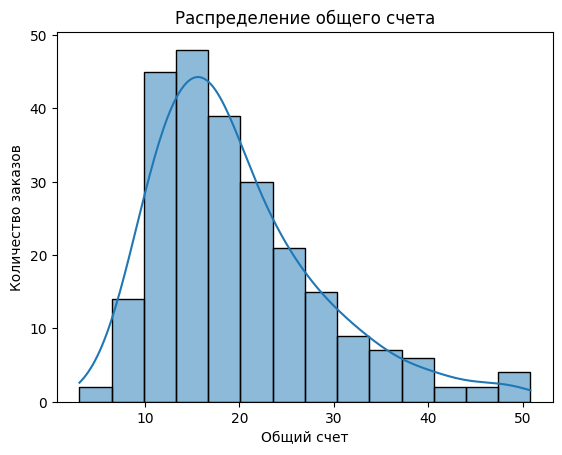

In [19]:
# Построим гистограмму total_bill

sns.histplot(df, x='total_bill', kde=True)
plt.title('Распределение общего счета')
plt.xlabel('Общий счет')
plt.ylabel('Количество заказов')
plt.show()

Вывод: распределение правостороннее асимметричное. Пик приходится на интервал 10-20, далее частота плавно снижается

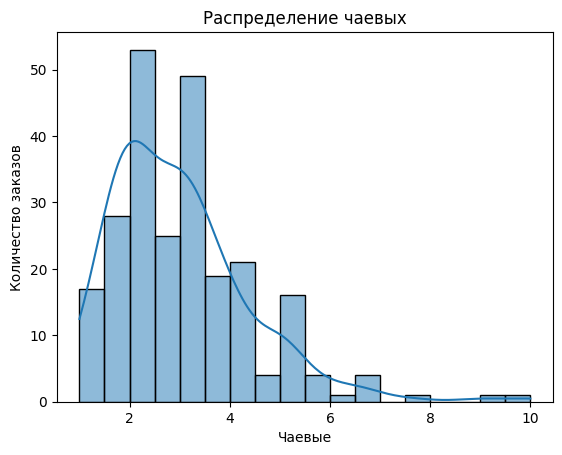

In [20]:
# Построим гистограмму tip

sns.histplot(df, x='tip', kde=True)
plt.title('Распределение чаевых')
plt.xlabel('Чаевые')
plt.ylabel('Количество заказов')
plt.show()

Вывод: распределение правосторонне асимметричное. Имеется два пика: 2-2.5 и 3-3.5. Имеется довольно длинный хвост из больших чаевых

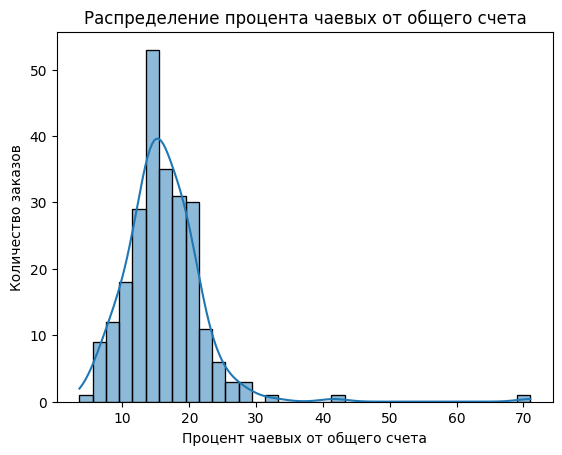

In [21]:
# Построим гистограмму tip_percent

sns.histplot(df, x='tip_percent', kde=True)
plt.title('Распределение процента чаевых от общего счета')
plt.xlabel('Процент чаевых от общего счета')
plt.ylabel('Количество заказов')
plt.show()

Вывод: распределение правостороннее асимметричное. Наиболее часто чаевые составляли около 15 процентов от счета. Имеется длинный хвост чаевых вплоть до 70 процентов от счета

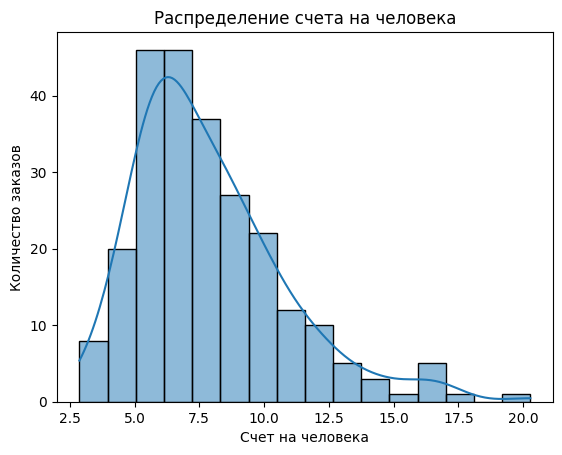

In [22]:
# Построим гистограмму bill_per_person

sns.histplot(df, x='bill_per_person', kde=True)
plt.title('Распределение счета на человека')
plt.xlabel('Счет на человека')
plt.ylabel('Количество заказов')
plt.show()

Вывод: распределение правосторонее асимметричное. Пик распределения приходится на 5-7 долларов на человека. Далее частота постепенно снижается, а длинный правый хвост отражает отдельные крупные чеки (вплоть до 20+ долларов на человека)

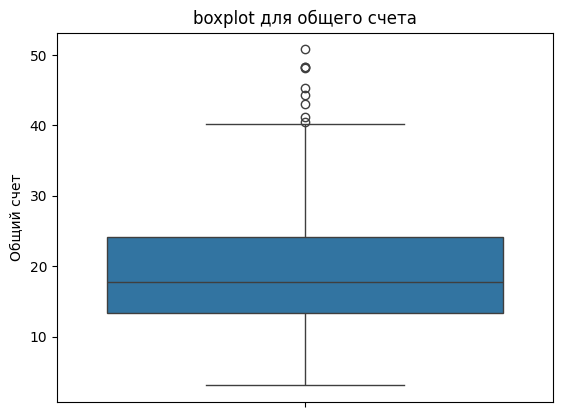

In [23]:
# Построим boxplot для total_bill

sns.boxplot(df, y='total_bill')
plt.title('boxplot для общего счета')
plt.ylabel('Общий счет')
plt.show()

Вывод: есть выбросы, но это не обязательно ошибки. Это может быть большая компания или люди заказывали дорогие блюда. Поэтому данные не являются ошибками и могут быть оставлены в датасете

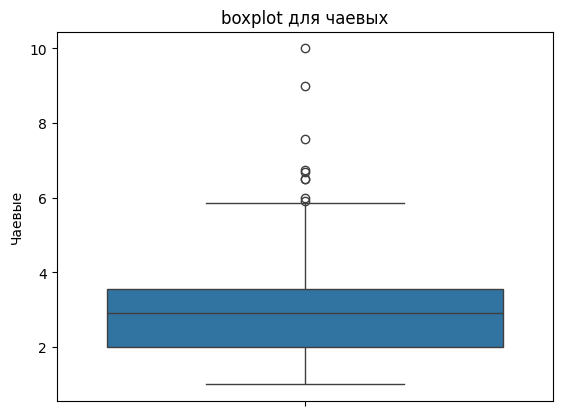

In [24]:
# Построим boxplot для tip

sns.boxplot(df, y='tip')
plt.title('boxplot для чаевых')
plt.ylabel('Чаевые')
plt.show()

Вывод: все, что более 6 долларов на графике отмечено как выбросы. Но эти чаевые вполне моли оставить щедрые клиенты, или была очень большая компания, или просто благодарность официанту. Поэтому данные не являются ошибками и могут быть оставлены в датасете

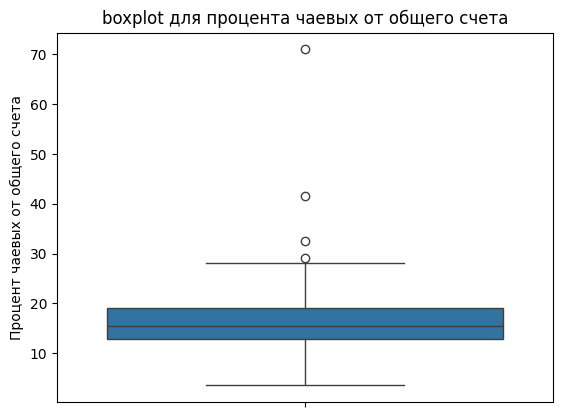

In [25]:
# Построим boxplot для tip_percent

sns.boxplot(df, y='tip_percent')
plt.title('boxplot для процента чаевых от общего счета')
plt.ylabel('Процент чаевых от общего счета')
plt.show()

Вывод: все чаевые, которые больше 30% от счета, на графике представлены как выбросы. Но скорее всего их оставли щедрые клиенты или общий счет был очень маленьким. Поэтому данные не являются ошибками и могут быть оставлены в датасете

---

## Задание 5. Анализ категорий

Необходимо:

1. Посчитать средние значения `total_bill`, `tip`, `tip_percent` по:
   - `sex`;
   - `smoker`;
   - `day`;
   - `time`;
   - `size`.
2. Построить barplot для среднего `tip` по `day`.
3. Построить barplot для среднего `tip_percent` по `time`.
4. Построить countplot количества заказов по `day`.
5. Сделать вывод.

Вопросы:

- Где больше заказов?
- Где выше средний счет?
- Где выше средний процент чаевых?

In [26]:
# Выведем средние значения total_bill, tip, tip_percent по sex

df_sex = (
    df.groupby('sex', observed=True)[['total_bill', 'tip', 'tip_percent']]
      .mean()
      .reset_index()
      .rename(columns={
          'total_bill': 'avg_total_bill',
          'tip': 'avg_tip',
          'tip_percent': 'avg_tip_percent'})
).round(2)
df_sex

,sex,avg_total_bill,avg_tip,avg_tip_percent
0,Male,20.74,3.09,15.77
1,Female,18.06,2.83,16.65


In [27]:
# Выведем средние значения total_bill, tip, tip_percent по smoker

df_smoker = (
    df.groupby('smoker', observed=True)[['total_bill', 'tip', 'tip_percent']]
      .mean()
      .reset_index()
      .rename(columns={
          'total_bill': 'avg_total_bill',
          'tip': 'avg_tip',
          'tip_percent': 'avg_tip_percent'})
).round(2)
df_smoker

,smoker,avg_total_bill,avg_tip,avg_tip_percent
0,Yes,20.76,3.01,16.32
1,No,19.19,2.99,15.93


In [28]:
# Выведем средние значения total_bill, tip, tip_percent по day

df_day = (
    df.groupby('day', observed=True)[['total_bill', 'tip', 'tip_percent']]
      .mean()
      .reset_index()
      .rename(columns={
          'total_bill': 'avg_total_bill',
          'tip': 'avg_tip',
          'tip_percent': 'avg_tip_percent'})
).round(2)
df_day

,day,avg_total_bill,avg_tip,avg_tip_percent
0,Thur,17.68,2.77,16.13
1,Fri,17.15,2.73,16.99
2,Sat,20.44,2.99,15.32
3,Sun,21.41,3.26,16.69


Вывод: наибольший средний счет в воскресенье (21.41 доллара), наименьший - в пятницу (17.15 доллара). Наибольший средний процент чаевых в пятницу (16.99 процентов от общего счета)

In [29]:
# Выведем средние значения total_bill, tip, tip_percent по time

df_time = (
    df.groupby('time', observed=True)[['total_bill', 'tip', 'tip_percent']]
      .mean()
      .reset_index()
      .rename(columns={
          'total_bill': 'avg_total_bill',
          'tip': 'avg_tip',
          'tip_percent': 'avg_tip_percent'})
).round(2)
df_time

,time,avg_total_bill,avg_tip,avg_tip_percent
0,Lunch,17.17,2.73,16.41
1,Dinner,20.80,3.10,15.95


In [30]:
# Выведем средние значения total_bill, tip, tip_percent по size

df_size = (
    df.groupby('size', observed=True)[['total_bill', 'tip', 'tip_percent']]
      .mean()
      .reset_index()
      .rename(columns={
          'total_bill': 'avg_total_bill',
          'tip': 'avg_tip',
          'tip_percent': 'avg_tip_percent'})
).round(2)
df_size

,size,avg_total_bill,avg_tip,avg_tip_percent
0,1,7.24,1.44,21.73
1,2,16.45,2.58,16.57
2,3,23.28,3.39,15.22
3,4,28.61,4.14,14.59
4,5,30.07,4.03,14.15
5,6,34.83,5.22,15.62


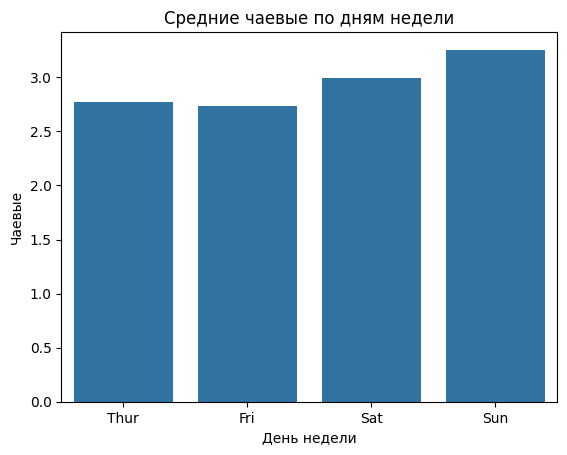

In [31]:
# Построим barplot для среднего tip по day

df_avg_tip_day = df.groupby('day', observed=True)['tip'].mean().reset_index()
sns.barplot(df_avg_tip_day, x='day', y='tip')
plt.title('Средние чаевые по дням недели')
plt.xlabel('День недели')
plt.ylabel('Чаевые')
plt.show()

Вывод: самые высокие средние чаевые оставляли в воскресенье (больше 3 долларов), самые низкие - в пятницу (около 2.7 доллара)

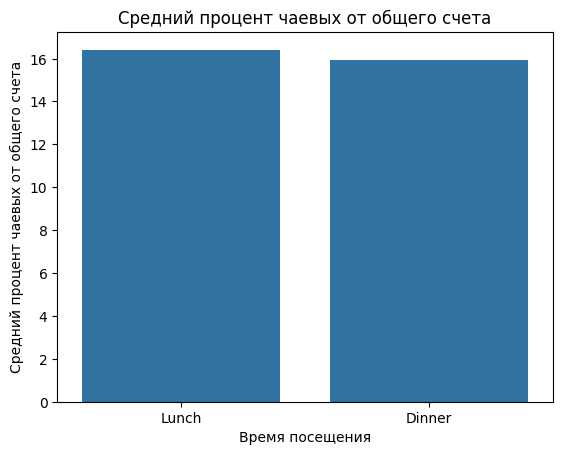

In [32]:
# Построим barplot для среднего tip_percent по time

df_avg_tip_percent_time = df.groupby('time', observed=True)['tip_percent'].mean().reset_index()
sns.barplot(df_avg_tip_percent_time, x='time', y='tip_percent')
plt.title('Средний процент чаевых от общего счета')
plt.xlabel('Время посещения')
plt.ylabel('Средний процент чаевых от общего счета')
plt.show()

Вывод: Средний процент чаевых практически не зависит от времени посещения. И в обед, и в ужин чаевые составляют около 16 процентов от заказа

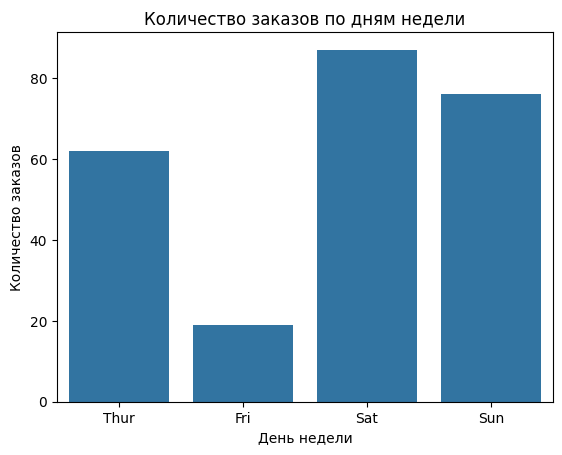

In [33]:
# Построим countplot количества заказов по day

sns.countplot(df, x='day')
plt.title('Количество заказов по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.show()

Вывод: наибольшее количество заказов приходится на субботу (более 80 заказов). Минимальное количество заказов в пятницу (менее 20). Самый большой средний счет в воскресенье (21.41 доллара), самый маленький средний счет - в пятницу (17.15 доллара). Наибольший средний процент чаевых в пятницу (почти 17 процентов от общего счета). Это связано с тем, что в пятницу бывают более мелкие заказы, где даже умеренные чаевые дают более высокий процент

---

## Задание 6. Корреляции и базовые зависимости

Необходимо:

1. Рассчитать корреляционную матрицу для числовых признаков.
2. Построить heatmap.
3. Построить scatter plot `total_bill` — `tip`.
4. Добавить линию регрессии.
5. Сделать вывод.

Вопросы:

- Какие числовые признаки связаны сильнее всего?
- Как связаны счет и чаевые?
- Есть ли связь между размером компании и чаевыми?

In [34]:
# Рассчитаем корреляционную матрицу для числовых признаков

df.select_dtypes(include='number').corr().round(2)

,total_bill,tip,size,tip_percent,bill_per_person,tip_per_person
total_bill,1.00,0.68,0.60,-0.34,0.65,0.24
tip,0.68,1.00,0.49,0.34,0.35,0.68
size,0.60,0.49,1.00,-0.14,-0.18,-0.25
tip_percent,-0.34,0.34,-0.14,1.00,-0.31,0.53
bill_per_person,0.65,0.35,-0.18,-0.31,1.00,0.54
tip_per_person,0.24,0.68,-0.25,0.53,0.54,1.00


Вывод: сильнее всего связаны между собой tip и tip_per_person, а также total_bill и tip

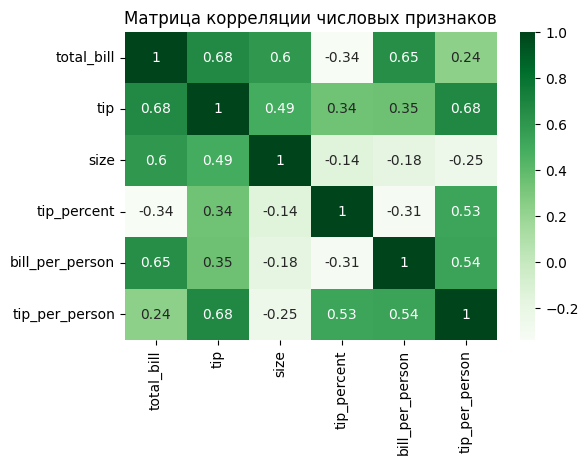

In [35]:
# Построим heatmap

plt.figure(figsize=(6, 4))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap="Greens")
plt.title('Матрица корреляции числовых признаков')
plt.show()

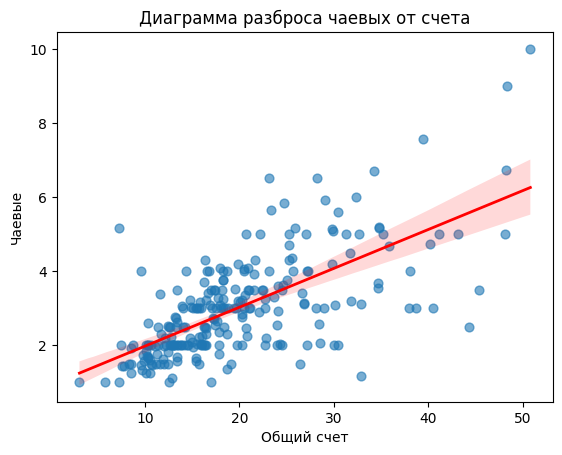

In [36]:
# Построим scatter plot total_bill — tip и добавим линию регрессии

sns.regplot(df, x='total_bill', y='tip', scatter_kws={'alpha': 0.6, 's': 40}, line_kws={'color': 'red', 'linewidth': 2})
plt.title('Диаграмма разброса чаевых от счета')
plt.xlabel('Общий счет')
plt.ylabel('Чаевые')
plt.show()

Вывод: положительная умеренно-сильная корреляция между total_bill и tip, а также между tip и tip_per_person (0.68). С увеличением счета растут чаевые. Между размером компании и чаевыми есть умеренная положительная корреляция (0.49)

---

## Дополнительное задание 7. Комбинированный анализ категорий

Проведите более сложный анализ сочетаний факторов.

Необходимо:

1. Сравнить `tip` по `day` с разбивкой по `time`.
2. Сравнить `tip_percent` по `sex` с разбивкой по `smoker`.
3. Сравнить `total_bill` по `day` с разбивкой по `smoker`.
4. Построить графики с параметром `hue`.
5. Создать хотя бы одну сводную таблицу по двум категориальным признакам.
6. Сделать вывод.

Примеры:

```python
sns.barplot(data=tips, x='day', y='tip', hue='time')
sns.boxplot(data=tips, x='day', y='total_bill', hue='smoker')
```

Вопросы:

- Какие комбинации категорий выделяются?
- Есть ли заметные различия между группами?
- Какие сравнения наиболее полезны?

In [37]:
# Сравним tip по day с разбивкой по time

df.pivot_table(
    index='day',
    columns='time',
    values='tip',
    observed=True
).round(2)

time,Lunch,Dinner
day,,
Thur,2.77,3.00
Fri,2.38,2.94
Sat,NaN,2.99
Sun,NaN,3.26


In [38]:
# Сравним tip_percent по sex с разбивкой по smoker

df.pivot_table(
    index='sex',
    columns='smoker',
    values='tip_percent',
    observed=True
).round(2)

smoker,Yes,No
sex,,
Male,15.28,16.07
Female,18.22,15.69


In [39]:
# Сравним total_bill по day с разбивкой по smoker

df.pivot_table(
    index='day',
    values='total_bill',
    columns='smoker',
    observed=True
).round(2)

smoker,Yes,No
day,,
Thur,19.19,17.11
Fri,16.81,18.42
Sat,21.28,19.66
Sun,24.12,20.51


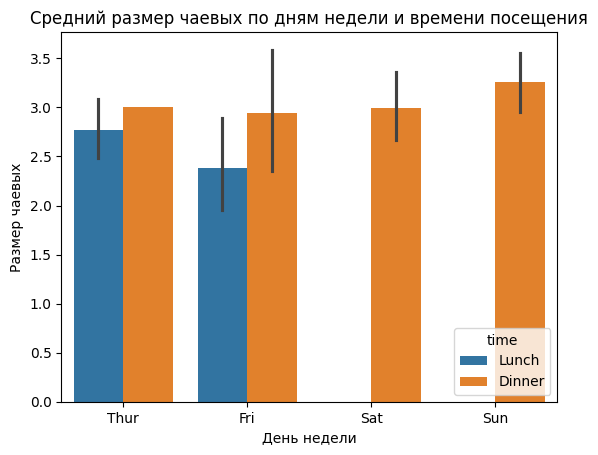

In [40]:
# Построим график среднего размера чаевых по дням недели и времени посещения

sns.barplot(data=df, x='day', y='tip', hue='time')
plt.title('Средний размер чаевых по дням недели и времени посещения')
plt.xlabel('День недели')
plt.ylabel('Размер чаевых')
plt.show()

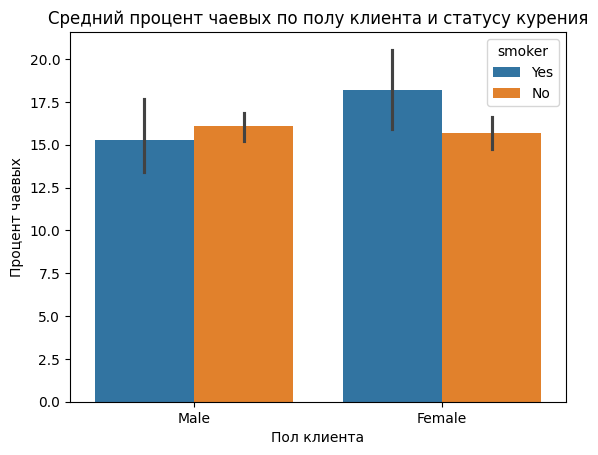

In [41]:
# Построим график среднего процента чаевых по полу клиента и статусу курения

sns.barplot(data=df, x='sex', y='tip_percent', hue='smoker')
plt.title('Средний процент чаевых по полу клиента и статусу курения')
plt.xlabel('Пол клиента')
plt.ylabel('Процент чаевых')
plt.show()

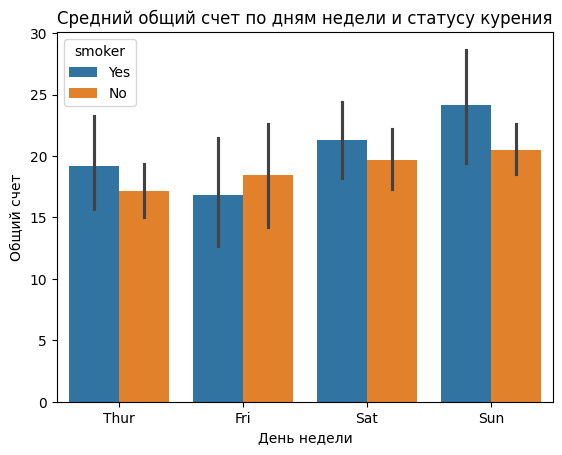

In [42]:
# Построим график среднего общего счета по дням недели и статусу курения

sns.barplot(data=df, x='day', y='total_bill', hue='smoker')
plt.title('Средний общий счет по дням недели и статусу курения')
plt.xlabel('День недели')
plt.ylabel('Общий счет')
plt.show()

Вывод: средний размер чаевых за ужины практически не зависит от дня недели и составляет около трех долларов. В воскресенье средний чек заметно выше (3.26 против ~2.99–3.00 в другие дни). Размер чаевых за обеды ниже и составляет 2.77 доллара в четверг, и 2.38 доллара в пятницу. Но обеды присутствуют только в четверг и пятницу, поэтому выводы по обедам менее надежны. Наибольший средний процент чаевых у курящих женщин - 18.22 процента от счета, в то время как курящие мужчины оставляют меньше чаевых, чем некурящие (15.28 % против 16.07 %). Влияние статуса курения неоднородно по дням недели. В четверг, субботу и воскресенье средний счет у курящих посетителей выше, а в пятницу наоборот. Разница в счете между курящими и некурящими варьируется от 1.62 до 3.61 доллара

---

## Дополнительное задание 8. Интерактивный мини-дашборд Plotly

Постройте набор интерактивных графиков.

Необходимо:

1. Импортировать `plotly.express`.
2. Построить интерактивный scatter:
   - `x='total_bill'`;
   - `y='tip'`;
   - `color='day'`;
   - `size='size'`;
   - `hover_data=['sex', 'smoker', 'time', 'tip_percent']`.
3. Построить интерактивный bar chart среднего `tip` по `day` и `time`.
4. Построить интерактивный boxplot `tip_percent` по `day`.
5. Построить интерактивный sunburst:
   - путь: `day → time → smoker`;
   - значение: `tip` или `total_bill`.
6. Сделать итоговый вывод по мини-дашборду.


In [43]:
# Импортируем plotly.express

import plotly.express as px

In [59]:
# Построим интерактивный scatter

fig = px.scatter(df,
                 x='total_bill',
                 y='tip', color='day',
                 size='size',
                 hover_data=['sex', 'smoker', 'time', 'tip_percent'],
                 title='Зависимость чаевых от общего счета по дням недели')
fig.show()

In [57]:
# Построим интерактивный bar chart среднего tip по day и time

df_agg = df.groupby(['day', 'time'], as_index=False, observed=True)['tip'].mean()
fig = px.bar(df_agg, x='day', y='tip', color='time', barmode='group')
fig.show()



In [50]:
# Построим интерактивный boxplot `tip_percent` по `day`

fig = px.box(df, x='tip_percent', y='day')
fig.show()

In [56]:
# Построим интерактивный sunburst

fig = px.sunburst(
    df,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='total_bill',
    color_continuous_scale='RdBu',
    title='Сумма счета',
    hover_data=['tip'])
fig.show()

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



Вывод:
- Scatterplot демонстрирует положительную связь между общим счетом и чаевыми. Цветовая кодировка по дням и размер точек (по размеру компании) позволяют видеть, что в субботу и воскресенье наблюдается больше крупных заказов
- Bar chart (Средние чаевые по дням и времени): Наглядно показывает превосходство чаевых на ужине над обедом. Но в выходные обедов нет, поэтому здесь выводы менее надежны
- Sunburst Chart (Иерархия day → time → smoker): Наиболее информативный график дашборда. Позволяет визуализировать вклад каждого сегмента. Визуально видно, что основной вклад в общую сумму выручки делают некурящие посетители на ужине в субботу и воскресенье.

##Итоговый вывод
Проведённый комплексный EDA датасета tips позволил выявить ключевые закономерности поведения клиентов и факторы, влияющие на размер чаевых.

- Связь чаевых и счёта. Между total_bill и tip наблюдается устойчивая положительная зависимость: с ростом счёта увеличиваются и чаевые. При этом анализ относительных метрик (tip_percent) показывает, что поведение клиентов неоднородно: например, курящие женщины оставляют самый высокий процент чаевых (18.22%), тогда как курящие мужчины — ниже, чем некурящие (15.28% против 16.07%). Это говорит о важности анализа не только абсолютных значений, но и долей.

- Влияние дня недели и времени. Наибольшее количество заказов приходится на субботу, а самый высокий средний счёт — на воскресенье. Чаевые за ужин стабильно выше, чем за обед, однако обеденные заказы представлены только в четверг и пятницу, поэтому прямое сравнение «обед vs ужин» по всем дням некорректно.

- Роль размера компании. Размер группы (size) является важным драйвером: он умеренно коррелирует с чаевыми (0.49) и напрямую влияет на абсолютную сумму чека. В выходные дни наблюдаются более крупные компании, что объясняет рост как среднего чека, так и суммарных чаевых.

- Статус курения. Влияние статуса курения на средний чек неоднородно по дням: в четверг, субботу и воскресенье средний счёт у курящих выше (разница до 3.61 $), а в пятницу — наоборот. Это указывает на то, что статус курения не является самостоятельным предиктором чека, а коррелирует с другими факторами (в частности, с размером компании и днём недели).

- Созданный интерактивный мини-дашборд (scatter, bar, box, sunburst) позволяет наглядно отслеживать эти зависимости. Наиболее информативным оказался sunburst-график: он наглядно демонстрирует, что наибольший объём выручки (суммарный счёт) формируется за счёт ужинов в выходные дни, преимущественно среди некурящих посетителей.

На основе анализа можно рекомендовать менеджменту ресторана:

- Усилить штат персонала в субботу и воскресенье — в эти дни фиксируется максимальная загрузка и самые высокие средние чеки.
- Контролировать качество обслуживания в сегментах с высоким процентом чаевых (например, группы, где могут быть курящие женщины) — это может быть маркером высокой удовлетворённости.
- При дальнейшем анализе использовать относительные метрики (tip_percent, bill_per_person) параллельно с абсолютными, чтобы точнее понимать поведение разных групп клиентов.